# GEEPatch: Sentinel-2 Dataset Construction Example

This notebook demonstrates how to use the `geepatch` package to download **mathematically aligned (Pixel-Perfect)** satellite imagery patches.

### 🎯 Objectives
1. Load **Sentinel-2** satellite imagery.
2. Divide the **Bochum** region into a fixed 256x256 grid.
3. Process and save each tile as an **8-bit RGB PNG** locally.
4. Verify the download using metadata (GPKG) and visualize the results.

In [1]:
# [Setup] Configure package path and Initialize GEE
import sys
import os
import ee
import geopandas as gpd
from PIL import Image
import matplotlib.pyplot as plt
import glob

print(os.getcwd())
sys.path.append(os.path.abspath('../../'))

# 1. Load Package
try:
    from gee_downloader import GEEPatch
    print("✅ GEEPatch package loaded successfully!")
except ImportError:
    print("❌ Package not found. Please check your current directory.")

# 2. Initialize Earth Engine (Required before defining Geometry)
try:
    ee.Initialize()
    print("✅ Google Earth Engine initialized!")
except Exception:
    print("⚠️ Authentication required. Triggering auth...")
    ee.Authenticate()
    ee.Initialize()
    print("✅ Google Earth Engine initialized via Auth!")

/raven/u/yhsuh/coding/patch_fetcher/examples/01_basic_usage
✅ GEEPatch package loaded successfully!
✅ Google Earth Engine initialized!


## 1. Define Region of Interest (ROI) and Data
We will define a region covering **Bochum and Essen** in the Ruhr industrial area.
We will filter for clear images (less than 5% cloud cover).

In [2]:
# 1. Define ROI (Essen ~ Bochum)
roi = ee.Geometry.Rectangle([7.10, 51.45, 7.25, 51.52])

# 2. Define Bands (True Color)
bands = ['B4', 'B3', 'B2']  # Red, Green, Blue

# 3. Filter Image Collection
s2_image = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(roi) \
    .filterDate('2023-06-01', '2023-08-30') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 5)) \
    .first() \
    .select(bands)

print("Data preparation complete.")

Data preparation complete.


## 2. Initialize and Run Downloader
Initialize the `GEEPatch` class. Workers are automatically scaled based on the system's CPU core count.

- **Zoom 14**: Optimal zoom level for Sentinel-2 resolution (~10m/px).
- **vis_params**: Normalizes raw reflectance (0~3000) to 8-bit (0~255).

In [3]:
# Output Directory
OUTPUT_DIR = './dataset_example_bochum'

# Initialize Instance
downloader = GEEPatch()

# Execute Download
gdf_meta = downloader.download_as_wmts_tiles(
    image=s2_image,
    roi=roi,
    output_dir=OUTPUT_DIR,
    zoom=14,
    bands=bands,
    vis_params={'min': [0, 0, 0], 'max': [4095, 4095, 4095]}  # Linear stretch for visualization
)

Google Earth Engine initialized successfully.


## 3. Verify Results (Metadata)
Check the status of downloaded tiles using the automatically generated `GeoPackage` file.

In [4]:
if gdf_meta is not None:
    print(f"Total Tiles: {len(gdf_meta)}")
    print("=== Status Summary ===")
    print(gdf_meta['status'].value_counts())
    display(gdf_meta.head())

Total Tiles: 42
=== Status Summary ===
status
success    42
Name: count, dtype: int64


,tile_index,x,y,zoom,label,filename,geometry,status,error
0,0,8515,5447,14,None,8515_5447_14_idx0.png,"POLYGON ((792499.109 6711782.58, 792499.109 67...",success,None
1,1,8515,5448,14,None,8515_5448_14_idx1.png,"POLYGON ((792499.109 6709336.595, 792499.109 6...",success,None
2,2,8515,5449,14,None,8515_5449_14_idx2.png,"POLYGON ((792499.109 6706890.61, 792499.109 67...",success,None
3,3,8515,5450,14,None,8515_5450_14_idx3.png,"POLYGON ((792499.109 6704444.625, 792499.109 6...",success,None
4,4,8515,5451,14,None,8515_5451_14_idx4.png,"POLYGON ((792499.109 6701998.64, 792499.109 67...",success,None


## 4. Visualize Images (Sampling)
Open random PNG files to visually verify that there are no artifacts or normalization errors.

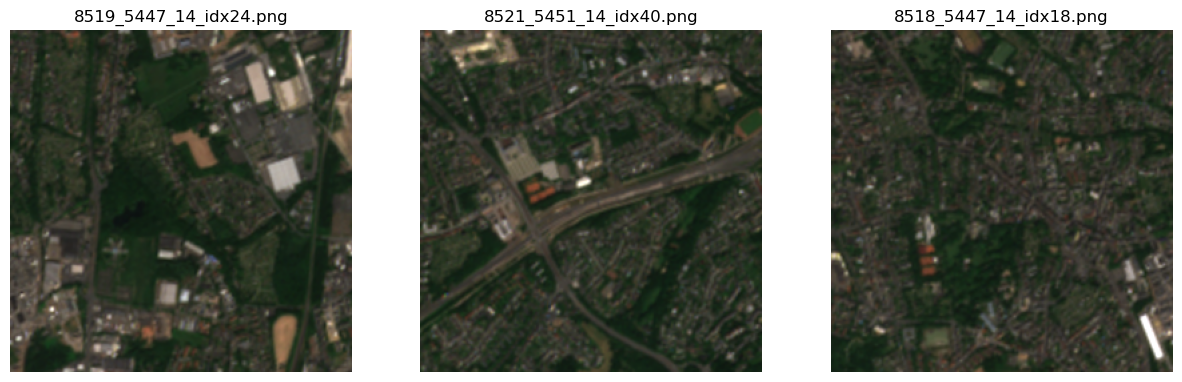

In [5]:
# Randomly select 3 PNG files
png_files = glob.glob(os.path.join(OUTPUT_DIR, "*.png"))
sample_files = png_files[:3]

if sample_files:
    plt.figure(figsize=(15, 5))
    for i, file_path in enumerate(sample_files):
        img = Image.open(file_path)
        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.title(os.path.basename(file_path))
        plt.axis('off')
    plt.show()
else:
    print("No images found.")